# **Model 2: Delta - Long Short Term Memory**

(Given the copies of plots in the markdown, if it's not visible in git or editors)

I will build simple LSTM, but instead of raw price series, I'm modelling the change in price. Then I will turn back to them to level series from the predicted deltas. After training, I will evaluate using a rolling 1-step forecast on the last 90 days, and finally will generate a 24-month forecast with a basic 95% uncertainity band.

## **Model Theoritical explanation**

The raw oil price series is non-stationary, which means it drifts and do a lot of swings over time. Deep models trained on non-stationary levels can learn a trend that looks good in sample but becomes unstable when rolled forward. So, to make the learning problem a bit clear, I modelled the delta series,
$$
\Delta y_t = y_t - y_{t-1}
$$

An LSTM is a recurrent neural network designed to learn patterns in sequences. Given the last $L$ timesteps of input, it produces a prediction for the next value. The input sequence is the last $L$ deltas,
$$
(\Delta y_{t-L}, \ldots, \Delta y_{t-1}) \;\rightarrow\; \widehat{\Delta y_t}
$$
I use $L=30$, which means the model sees the last 30 daily changes and predicts the next day’s change.

Once I have $\widehat{\Delta y_t}$, I reconstructed the predicted price,

$$
\hat{y}_t = y_{t-1} + \widehat{\Delta y_t}
$$

For multi-step forecasting, I repeated this forward in time by feeding the model its latest predicted deltas. Since small bias can accumulate over long horizons, I cliped extreme predicted deltas to a realistic range based on the training data. The LSTM is not probabilistic by default, so I build a practical 95% interval by bootstrapping delta residuals (noise) from training and simulating many forecast paths. The 2.5% and 97.5% quantiles across paths form the 95% band.

## **Imports**

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import os
import warnings
warnings.filterwarnings("ignore")

import plotly.graph_objects as go
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## **Loading the data**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/oil_prices_2426.csv')
df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df = df.sort_values("date").set_index("date")

y = df["price (dollars)"].astype(float).asfreq("D")

print("Loaded")
print("Start:", y.index.min(), "| End:", y.index.max(), "| n:", len(y))

Loaded
Start: 2024-09-21 00:00:00 | End: 2026-02-02 00:00:00 | n: 500


## **Config**

In [ ]:
TEST_DAYS = 90
LOOKBACK = 30

EPOCHS = 60
BATCH = 32
LR = 1e-3

N_SIMS = 400
CLIP_Q = (0.01, 0.99)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)
np.random.seed(42)

print("Device:", DEVICE)

Device: cuda


## **Train/Test Split**

In [ ]:
y_train = y.iloc[:-TEST_DAYS]
y_test  = y.iloc[-TEST_DAYS:]

fig = go.Figure()
fig.add_trace(go.Scatter(x=y_train.index, y=y_train.values, name="Train", line=dict(width=2)))
fig.add_trace(go.Scatter(x=y_test.index,  y=y_test.values,  name="Test",  line=dict(width=2)))
fig.update_layout(template="plotly_white", title=dict(text="Train/Test split (Price)", x=0.5),
                  xaxis_title="Date", yaxis_title="USD",
                  font=dict(size=14), margin=dict(l=60, r=30, t=70, b=60))
fig.show()

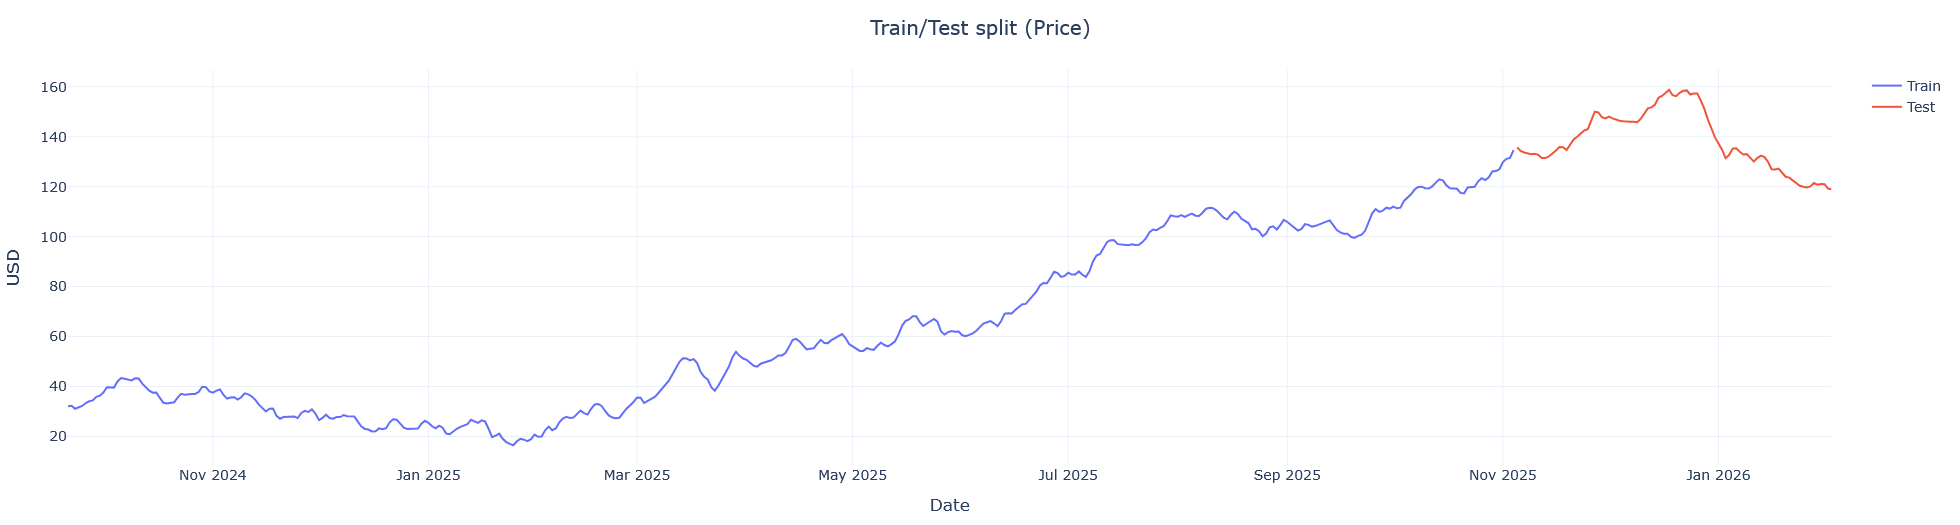

## **Creating delta series and scaling it**

Instead of predicting the price level directly, I modelled the daily change. This keeps the learning target closer to stationary and makes long-horizon forecasts less likely to drift or explode. I fitted the scaler only on training deltas to avoid leaking information from the test set.

In [ ]:
dy = y.diff().dropna()
dy_train = y_train.diff().dropna()
dy_test  = y_test.diff().dropna()
scaler = StandardScaler()
dy_train_s = scaler.fit_transform(dy_train.values.reshape(-1, 1)).astype(np.float32).flatten()
dy_all_s = scaler.transform(dy.values.reshape(-1, 1)).astype(np.float32).flatten()
lo_clip, hi_clip = np.quantile(dy_train.values, CLIP_Q)
print("Delta clip bounds:", lo_clip, hi_clip)

Delta clip bounds: -2.9292000000000034 3.4588000000000143


## **Building sequences**

I turned the delta series into a supervised learning dataset, where each input is the last 30 days of deltas, and the target is the next day’s delta.

In [ ]:
def make_sequences(arr_1d, lookback):
    """
    Convert a 1D sequence into supervised samples for LSTM training
    """
    X, y = [], []
    for i in range(lookback, len(arr_1d)):
        X.append(arr_1d[i-lookback:i])
        y.append(arr_1d[i])
    X = np.array(X, dtype=np.float32)[:, :, None]
    y = np.array(y, dtype=np.float32)[:, None]
    return X, y

X_train_all, y_train_all = make_sequences(dy_train_s, LOOKBACK)
val_n = max(1, int(0.18 * len(X_train_all)))
X_train, y_train_l = X_train_all[:-val_n], y_train_all[:-val_n]
X_val, y_val = X_train_all[-val_n:], y_train_all[-val_n:]

print("Train:", X_train.shape, y_train_l.shape)
print("Val  :", X_val.shape, y_val.shape)

Train: (311, 30, 1) (311, 1)
Val  : (68, 30, 1) (68, 1)


## **Data Loader**

In [ ]:
class SeqDataset(Dataset):
    """
    Simple PyTorch Dataset wrapper for (sequence, target) arrays
    """
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, y_train_l), batch_size=BATCH, shuffle=True, drop_last=False)
val_loader   = DataLoader(SeqDataset(X_val, y_val), batch_size=BATCH, shuffle=False, drop_last=False)

## **LSTM model definition**

This is a simple 1-layer LSTM with a small hidden state and a single linear output. I had it small on purpose because the dataset is small. Bigger models would just learn noise.

In [ ]:
class DeltaLSTM(nn.Module):
    """
    Single-layer LSTM that predicts the next scaled delta from a lookback window of past deltas
    """
    def __init__(self, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = DeltaLSTM(hidden=32).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

## **Model Training**

I trained using MSE loss and Adam. I also cliped gradients to avoid unstable updates. I kept the best validation checkpoint rather than trusting the final epoch.

In [ ]:
def run_epoch(loader, train=True):
    """
    Run one pass over a DataLoader and return the average MSE
    """
    model.train(train)
    total = 0.0
    n = 0
    for Xb, yb in loader:
        Xb = Xb.to(DEVICE)
        yb = yb.to(DEVICE)

        if train:
            opt.zero_grad()

        pred = model(Xb)
        loss = loss_fn(pred, yb)

        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        total += float(loss.item()) * len(Xb)
        n += len(Xb)
    return total / n

train_losses, val_losses = [], []
best_val = np.inf
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader, train=False)
    train_losses.append(tr)
    val_losses.append(va)

    if va < best_val:
        best_val = va
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)

fig = go.Figure()
fig.add_trace(go.Scatter(y=train_losses, name="train"))
fig.add_trace(go.Scatter(y=val_losses, name="val"))
fig.update_layout(template="plotly_white", title=dict(text="Delta-LSTM training loss", x=0.5),
                  xaxis_title="Epoch", yaxis_title="MSE",
                  font=dict(size=14), margin=dict(l=60, r=30, t=70, b=60))
fig.show()

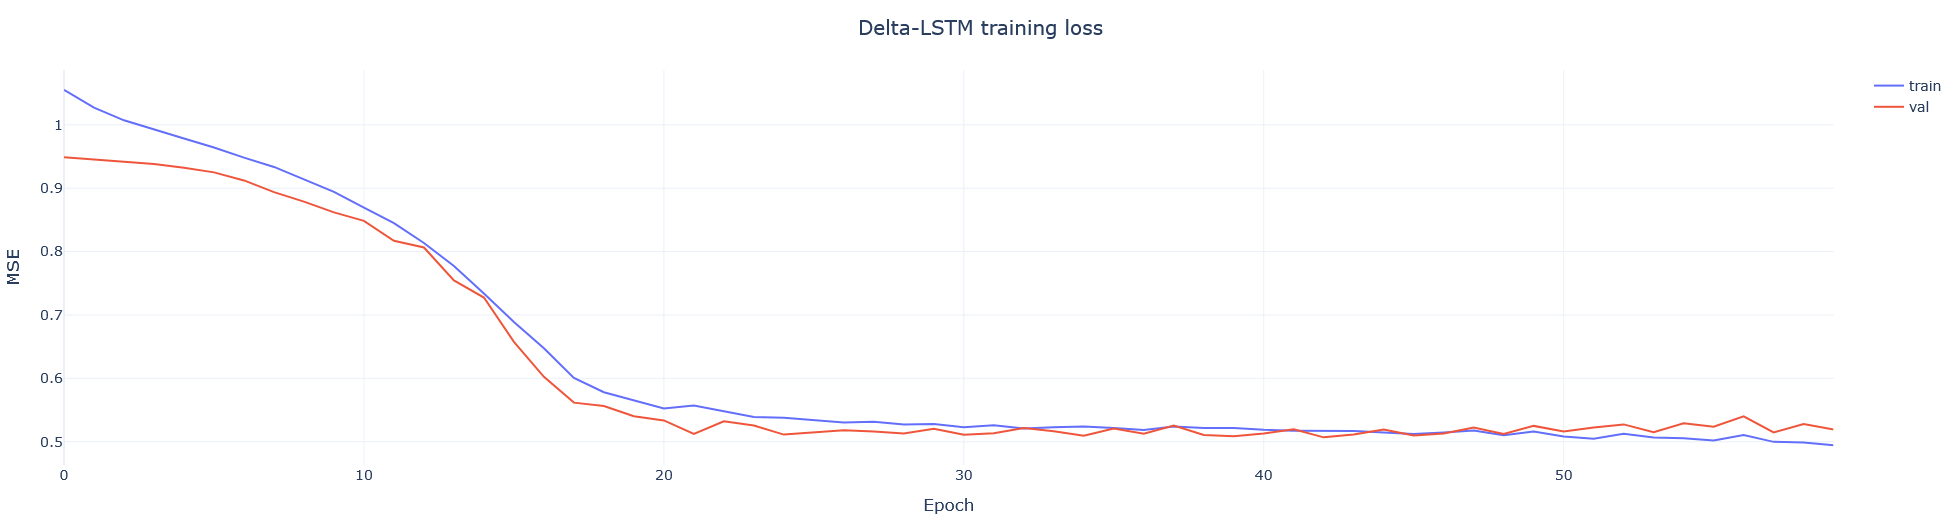

Both train and validation loss drop smoothly and then flatten out around the same region. I can say that the training is stable and not obviously overfitting.

## **Rolling 1-step test evaluation**

For evaluation, I did a rolling 1-step prediction on the test period. That means each prediction uses real past information, not a long recursive chain.

In [ ]:
dy_s = dy_all_s
X_all, y_all = make_sequences(dy_s, LOOKBACK)
dy_index = dy.index
seq_end_dates = dy_index[LOOKBACK:]
test_mask = (seq_end_dates >= y_test.index.min()) & (seq_end_dates <= y_test.index.max())
X_test = X_all[test_mask]
test_dates = seq_end_dates[test_mask]

model.eval()
with torch.no_grad():
    pred_s = model(torch.from_numpy(X_test).to(DEVICE)).cpu().numpy().flatten()

pred_delta = scaler.inverse_transform(pred_s.reshape(-1, 1)).flatten()
pred_price = []
for dt, dlt in zip(test_dates, pred_delta):
    prev_day = dt - pd.Timedelta(days=1)
    pred_price.append(y.loc[prev_day] + dlt)

pred_price = np.array(pred_price, float)
true_price = y.loc[test_dates].values

rmse_lstm = float(np.sqrt(mean_squared_error(true_price, pred_price)))
print("Delta-LSTM RMSE (rolling 1-step):", rmse_lstm)

Delta-LSTM RMSE (rolling 1-step): 1.1318239336487557


## **Plotting the 1-step test forecast**

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=y_train.index, y=y_train.values, name="Train", line=dict(width=2)))
fig.add_trace(go.Scatter(x=test_dates, y=true_price, name="Test (aligned)", line=dict(width=2)))
fig.add_trace(go.Scatter(x=test_dates, y=pred_price, name="Delta-LSTM 1-step", line=dict(width=2)))

fig.update_layout(template="plotly_white",
                  title=dict(text="Delta-LSTM: rolling 1-step test forecast", x=0.5),
                  xaxis_title="Date", yaxis_title="USD",
                  font=dict(size=14), margin=dict(l=60, r=30, t=70, b=60))
fig.show()

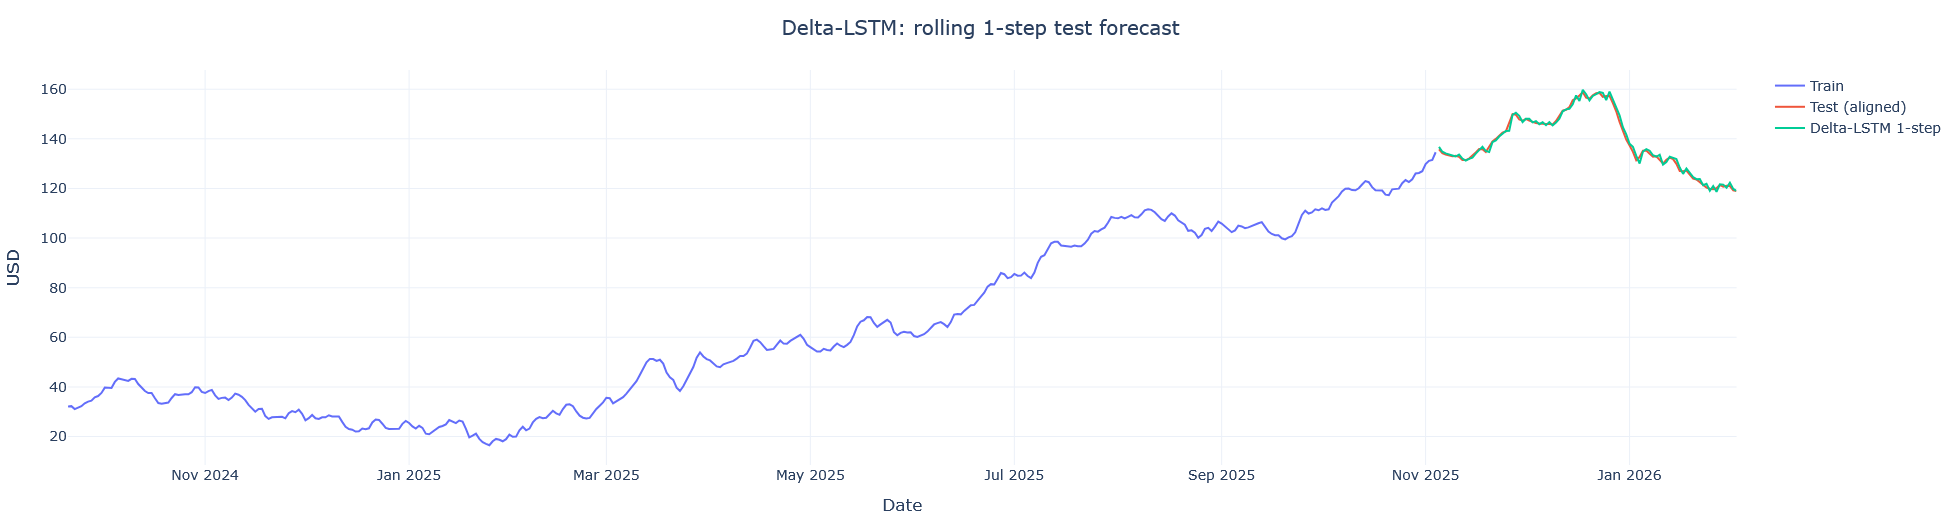

The delta-LSTM line hugs the test line closely through the peak and the decline, with only small deviations.

## **24-month forecast**

In [ ]:
fc_start = y.index.max() + pd.Timedelta(days=1)
fc_end   = y.index.max() + pd.DateOffset(months=24)
fc_dates = pd.date_range(fc_start, fc_end, freq="D")
H = len(fc_dates)
window = dy_s[-LOOKBACK:].copy()

def rollout_path(noise=None, seed_price=float(y.iloc[-1])):
    """
    Roll the Delta-LSTM forward for H days to generate a price path, optionally adding noise to each predicted delta
    """
    w = window.copy()
    price = float(seed_price)
    out = np.zeros(H, float)

    for t in range(H):
        x = torch.from_numpy(w.reshape(1, LOOKBACK, 1)).to(DEVICE)
        with torch.no_grad():
            d_s = float(model(x).cpu().numpy().item())

        d = float(scaler.inverse_transform([[d_s]])[0, 0])
        if noise is not None:
            d += float(noise[t])

        d = float(np.clip(d, lo_clip, hi_clip))

        price = price + d
        out[t] = price

        w = np.roll(w, -1)
        w[-1] = d_s

    return out

mean_path = rollout_path(noise=None)

## **Confidence interval with bootstrap noise**

To add uncertainty, I simulated multiple forecast paths by adding bootstrapped residual noise to predicted deltas, then reconstructed the price path. This gives a practical 95% band without adding a full probabilistic neural net.

In [ ]:
model.eval()
with torch.no_grad():
    pred_train_s = model(torch.from_numpy(X_train_all).to(DEVICE)).cpu().numpy().flatten()

true_train_delta = scaler.inverse_transform(y_train_all.reshape(-1, 1)).flatten()
pred_train_delta = scaler.inverse_transform(pred_train_s.reshape(-1, 1)).flatten()
resid_delta = true_train_delta - pred_train_delta

rng = np.random.default_rng(42)
paths = np.zeros((N_SIMS, H), float)

for s in range(N_SIMS):
    noise = rng.choice(resid_delta, size=H, replace=True)
    paths[s] = rollout_path(noise=noise)

lower = np.quantile(paths, 0.025, axis=0)
upper = np.quantile(paths, 0.975, axis=0)

## **Plotting 24-month forecast with 95% CI**

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=y.index, y=y.values, name="Historical", line=dict(width=2)))

fig.add_trace(go.Scatter(x=fc_dates, y=upper, line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=fc_dates, y=lower, fill="tonexty", name="95% CI", line=dict(width=0)))

fig.add_trace(go.Scatter(x=fc_dates, y=mean_path, name="Forecast (mean)", line=dict(width=2)))

fig.update_layout(template="plotly_white",
                  title=dict(text="Delta-LSTM: 24-month forecast + 95% CI", x=0.5),
                  xaxis_title="Date", yaxis_title="USD",
                  font=dict(size=14), margin=dict(l=60, r=30, t=70, b=60))
fig.show()

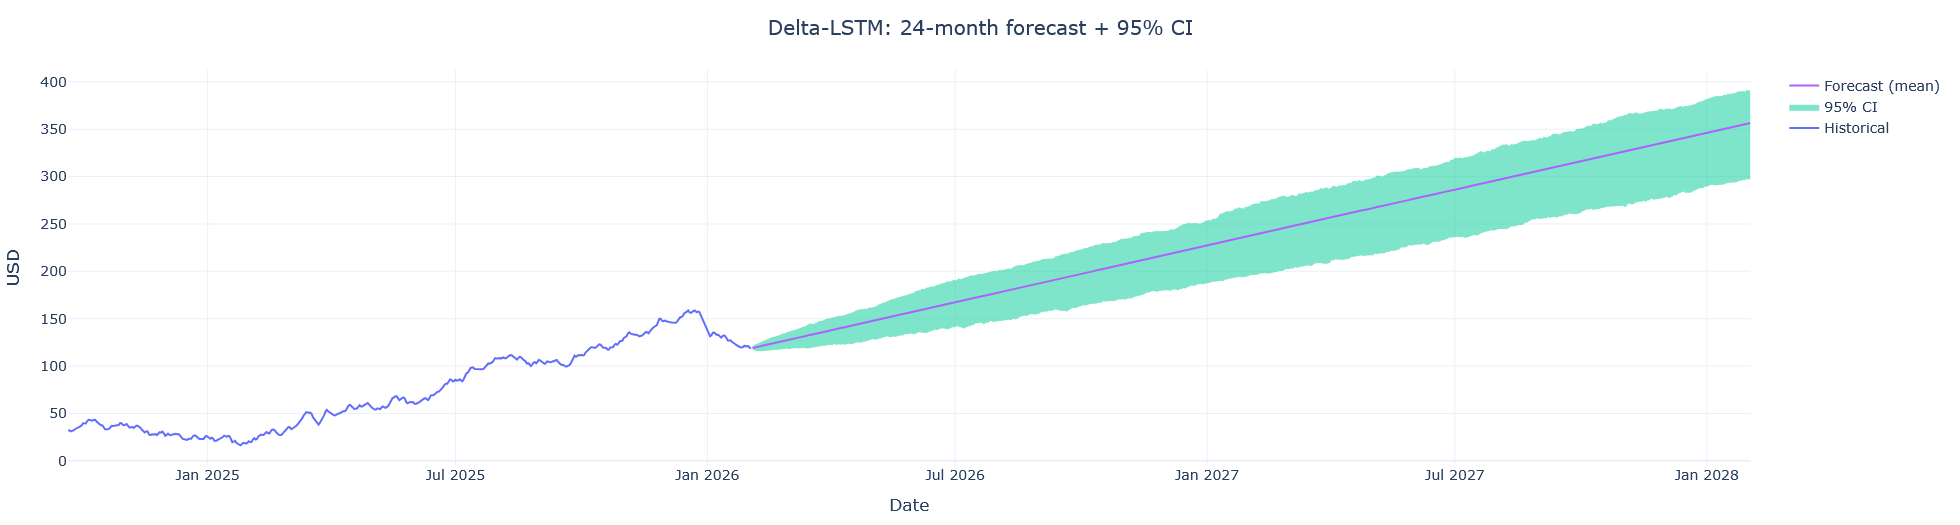

The interval widens gradually over time, like expected. The mean path trends upward because the model is effectively learning an average positive drift in deltas during the last window.

## **Saving the model**

I saved the trained network weights, scaler stats, clipping bounds, and RMSE to do a final comparison and may be for deployment.

In [ ]:
out_dir = Path("../models")
out_dir.mkdir(parents=True, exist_ok=True)

torch.save({
    "state_dict": model.state_dict(),
    "lookback": LOOKBACK,
    "scaler_mean": scaler.mean_,
    "scaler_scale": scaler.scale_,
    "clip_bounds": (float(lo_clip), float(hi_clip)),
    "rmse_rolling_1step": rmse_lstm,
}, out_dir / "lstm_delta.pt")

print("Saved:", out_dir / "lstm_delta.pt")

Saved: ../models/lstm_delta.pt
